In [1]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.12.4 (tags/v3.12.4:8e8a4ba, Jun  6 2024, 19:30:16) [MSC v.1940 64 bit (AMD64)]
Python executable: d:\ML project\FairFraud\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

print("XGBoost version:", xgb.__version__)

df = pd.read_csv("../data/Base.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

XGBoost version: 3.4.1
Dataset shape: (1000000, 32)

Columns:
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


In [3]:
# Target distribution
print(df["fraud_bool"].value_counts())
print("\nFraud percentage:")
print(df["fraud_bool"].mean() * 100)

# Data types
print("\nData types:")
print(df.dtypes)

fraud_bool
0    988971
1     11029
Name: count, dtype: int64

Fraud percentage:
1.1029

Data types:
fraud_bool                            int64
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                            str
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                       str
credit_risk_score                     int64
email_is_free                         int64
housing_status                          str
phone_home_valid                      int64
phone_mobile_valid  

In [4]:
# Separate target from features
X = df.drop(columns=["fraud_bool"])
y = df["fraud_bool"]

# Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))

print("\nNumber of numerical columns:", len(numerical_cols))
print(numerical_cols)

Categorical columns:
['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

Number of categorical columns: 5

Number of numerical columns: 26
['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


C:\Users\dell\AppData\Local\Temp\ipykernel_13908\4012245976.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [5]:
# Temporal split used by the team

train_df = df[df["month"] < 5].copy()

val_df = df[
    (df["month"] >= 5) &
    (df["month"] < 6)
].copy()

test_df = df[df["month"] >= 6].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nFraud rate:")
print("Train:", train_df["fraud_bool"].mean() * 100)
print("Validation:", val_df["fraud_bool"].mean() * 100)
print("Test:", test_df["fraud_bool"].mean() * 100)

Train shape: (675666, 32)
Validation shape: (119323, 32)
Test shape: (205011, 32)

Fraud rate:
Train: 0.9975342846909568
Validation: 1.182504630289215
Test: 1.4038271117159566


In [6]:
# Separate features and target for each split

X_train = train_df.drop(columns=["fraud_bool"])
y_train = train_df["fraud_bool"]

X_val = val_df.drop(columns=["fraud_bool"])
y_val = val_df["fraud_bool"]

X_test = test_df.drop(columns=["fraud_bool"])
y_test = test_df["fraud_bool"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (675666, 31)
y_train: (675666,)
X_val: (119323, 31)
y_val: (119323,)
X_test: (205011, 31)
y_test: (205011,)


In [7]:
# Convert categorical features to pandas category dtype

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    X_test[col] = X_test[col].astype("category")

print("Categorical columns:")
for col in categorical_cols:
    print(f"{col}: {X_train[col].dtype}")

Categorical columns:
payment_type: category
employment_status: category
housing_status: category
source: category
device_os: category


In [8]:
# Calculate class imbalance ratio for XGBoost

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Non-fraud samples:", negative)
print("Fraud samples:", positive)
print("scale_pos_weight:", scale_pos_weight)

Non-fraud samples: 668926
Fraud samples: 6740
scale_pos_weight: 99.24718100890207


In [9]:
# Train vanilla XGBoost baseline

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("XGBoost baseline trained successfully!")

XGBoost baseline trained successfully!


In [10]:
# Generate fraud probabilities

val_probs = model.predict_proba(X_val)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

print("Validation predictions generated:", len(val_probs))
print("Test predictions generated:", len(test_probs))

Validation predictions generated: 119323
Test predictions generated: 205011


In [11]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score
)

# Use 0.5 as the initial/default classification threshold
val_pred = (val_probs >= 0.5).astype(int)
test_pred = (test_probs >= 0.5).astype(int)

print("===== VALIDATION =====")
print("AUC-PR:", average_precision_score(y_val, val_probs))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))
print("Precision:", precision_score(y_val, val_pred, zero_division=0))
print("Recall:", recall_score(y_val, val_pred, zero_division=0))

print("\n===== TEST =====")
print("AUC-PR:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("Precision:", precision_score(y_test, test_pred, zero_division=0))
print("Recall:", recall_score(y_test, test_pred, zero_division=0))

===== VALIDATION =====
AUC-PR: 0.1756638848839741
ROC-AUC: 0.8906366627415302
Precision: 0.08146805618486633
Recall: 0.6371367824238129

===== TEST =====
AUC-PR: 0.16909883577052143
ROC-AUC: 0.8825916527269334
Precision: 0.10214206502072025
Recall: 0.6080611535788742


In [12]:
from sklearn.metrics import roc_curve

def recall_at_fpr(y_true, probabilities, target_fpr=0.01):
    fpr, tpr, thresholds = roc_curve(y_true, probabilities)

    valid = np.where(fpr <= target_fpr)[0]

    if len(valid) == 0:
        return 0.0, None

    best_idx = valid[np.argmax(tpr[valid])]

    return tpr[best_idx], thresholds[best_idx]


val_recall, val_threshold = recall_at_fpr(
    y_val,
    val_probs,
    target_fpr=0.01
)

test_recall, test_threshold = recall_at_fpr(
    y_test,
    test_probs,
    target_fpr=0.01
)

print("===== RECALL @ 1% FPR =====")

print("Validation Recall:", val_recall)
print("Validation Threshold:", val_threshold)

print("\nTest Recall:", test_recall)
print("Test Threshold:", test_threshold)

===== RECALL @ 1% FPR =====
Validation Recall: 0.27002126151665484
Validation Threshold: 0.8801289200782776

Test Recall: 0.226546212647672
Test Threshold: 0.872409999370575


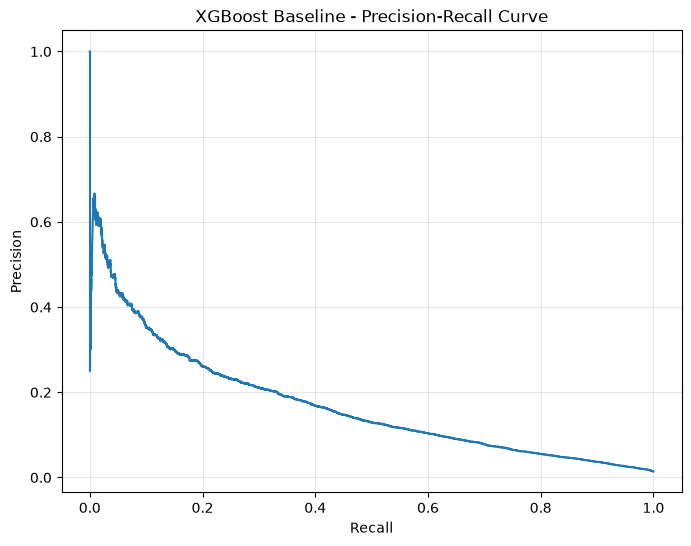

In [13]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_probs
)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Baseline - Precision-Recall Curve")
plt.grid(alpha=0.3)

plt.show()

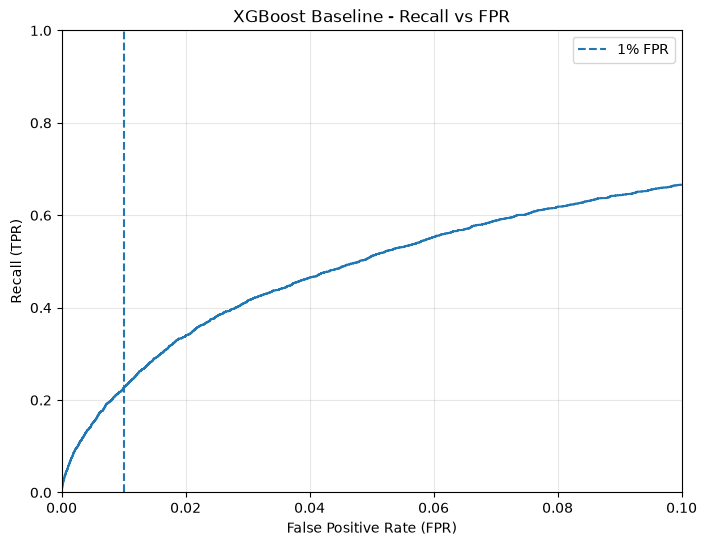

In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, test_probs)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr)

# Mark our 1% FPR operating point
plt.axvline(
    x=0.01,
    linestyle="--",
    label="1% FPR"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("Recall (TPR)")
plt.title("XGBoost Baseline - Recall vs FPR")
plt.xlim(0, 0.10)
plt.ylim(0, 1.0)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [15]:
# Age distribution across the test set

print("Age statistics:")
print(X_test["customer_age"].describe())

print("\nUnique ages:")
print(sorted(X_test["customer_age"].unique()))

Age statistics:
count    205011.000000
mean         33.783017
std          11.766521
min          10.000000
25%          20.000000
50%          30.000000
75%          40.000000
max          90.000000
Name: customer_age, dtype: float64

Unique ages:
[np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90)]


In [16]:
from sklearn.metrics import confusion_matrix

age_fairness = []

for age in sorted(X_test["customer_age"].unique()):

    mask = X_test["customer_age"] == age

    y_true_age = y_test[mask]
    y_pred_age = test_pred[mask]

    tn, fp, fn, tp = confusion_matrix(
        y_true_age,
        y_pred_age,
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

    age_fairness.append({
        "age": int(age),
        "FPR": fpr,
        "TPR": tpr
    })

fairness_df = pd.DataFrame(age_fairness)

print(fairness_df)

   age       FPR       TPR
0   10  0.019314  0.272727
1   20  0.029306  0.381877
2   30  0.057740  0.501401
3   40  0.087275  0.626777
4   50  0.161024  0.744444
5   60  0.183126  0.740072
6   70  0.188041  0.779412
7   80  0.203704  0.857143
8   90  0.375000  0.000000


In [17]:
# Check sample sizes for each age group

age_counts = []

for age in sorted(X_test["customer_age"].unique()):

    mask = X_test["customer_age"] == age

    total = mask.sum()
    fraud = y_test[mask].sum()
    non_fraud = total - fraud

    age_counts.append({
        "age": int(age),
        "total": int(total),
        "fraud": int(fraud),
        "non_fraud": int(non_fraud)
    })

age_counts_df = pd.DataFrame(age_counts)

print(age_counts_df)

   age  total  fraud  non_fraud
0   10   5096     22       5074
1   20  46341    309      46032
2   30  63322    714      62608
3   40  56473    844      55629
4   50  25676    630      25046
5   60   6464    277       6187
6   70   1339     68       1271
7   80    284     14        270
8   90     16      0         16


In [18]:
# Filter age groups with enough positive and negative examples

MIN_FRAUD = 10
MIN_NON_FRAUD = 10

valid_ages = age_counts_df[
    (age_counts_df["fraud"] >= MIN_FRAUD) &
    (age_counts_df["non_fraud"] >= MIN_NON_FRAUD)
]["age"].tolist()

print("Age groups used for fairness analysis:")
print(valid_ages)

fairness_valid_df = fairness_df[
    fairness_df["age"].isin(valid_ages)
].copy()

print("\nFairness metrics:")
print(fairness_valid_df)

Age groups used for fairness analysis:
[10, 20, 30, 40, 50, 60, 70, 80]

Fairness metrics:
   age       FPR       TPR
0   10  0.019314  0.272727
1   20  0.029306  0.381877
2   30  0.057740  0.501401
3   40  0.087275  0.626777
4   50  0.161024  0.744444
5   60  0.183126  0.740072
6   70  0.188041  0.779412
7   80  0.203704  0.857143


In [19]:
# Calculate fairness gaps for vanilla XGBoost

tpr_gap = (
    fairness_valid_df["TPR"].max()
    - fairness_valid_df["TPR"].min()
)

fpr_gap = (
    fairness_valid_df["FPR"].max()
    - fairness_valid_df["FPR"].min()
)

print("===== XGBoost Fairness Baseline =====")
print(f"TPR gap: {tpr_gap:.4f} ({tpr_gap * 100:.2f}%)")
print(f"FPR gap: {fpr_gap:.4f} ({fpr_gap * 100:.2f}%)")

print("\nTPR range:")
print(
    f"{fairness_valid_df['TPR'].min():.4f}"
    f" → "
    f"{fairness_valid_df['TPR'].max():.4f}"
)

print("\nFPR range:")
print(
    f"{fairness_valid_df['FPR'].min():.4f}"
    f" → "
    f"{fairness_valid_df['FPR'].max():.4f}"
)

===== XGBoost Fairness Baseline =====
TPR gap: 0.5844 (58.44%)
FPR gap: 0.1844 (18.44%)

TPR range:
0.2727 → 0.8571

FPR range:
0.0193 → 0.2037


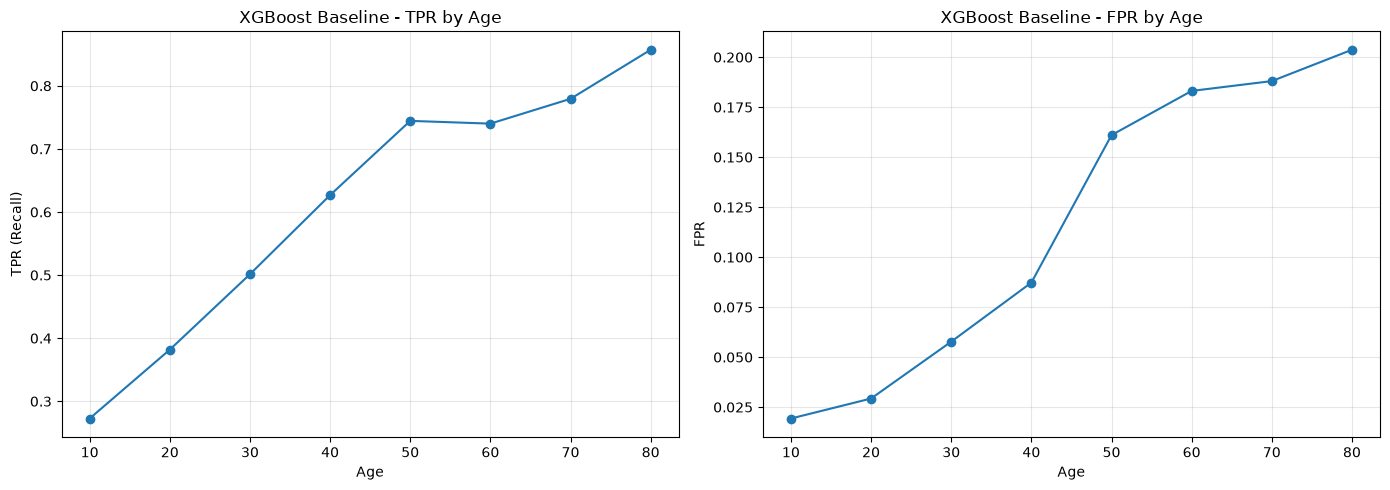

In [20]:
# Fairness baseline visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TPR by age
axes[0].plot(
    fairness_valid_df["age"],
    fairness_valid_df["TPR"],
    marker="o"
)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("TPR (Recall)")
axes[0].set_title("XGBoost Baseline - TPR by Age")
axes[0].grid(alpha=0.3)

# FPR by age
axes[1].plot(
    fairness_valid_df["age"],
    fairness_valid_df["FPR"],
    marker="o"
)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("FPR")
axes[1].set_title("XGBoost Baseline - FPR by Age")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()